# 2.10 — Optimisation d'hyperparamètres : grille, hasard, bayésien — et quand s'arrêter

**Navigation** : [<< 2.9-Grokking](2.9-Grokking-Generalisation.ipynb) | [2.11-Regression-Grande-Dimension >>](2.11-Regression-Grande-Dimension.ipynb) | [Index](../README.md)

**Kernel** : Python 3 · **Bibliothèque** : scikit-learn + Optuna · **Niveau** : intermédiaire · **Durée** : ~30 min · **CPU** : < 3 min

***

Le tuning d'hyperparamètres est le geste le plus répété et le moins enseigné du machine learning : on le croise partout — dans une recherche de données, dans le pipeline d'un agent, dans un sweep de production. Et pourtant il se réduit souvent à « je lance plein de combinaisons et je garde la meilleure ». Ce notebook montre que le *choix de la stratégie* et *le moment où l'on s'arrête* sont des décisions, pas des automatismes :

1. comment poser proprement le problème (modèle, budget d'essais, espace de recherche mixte) ;
2. pourquoi la **grille exhaustive** explose en dimension, et ce qu'elle coûte ;
3. pourquoi le **hasard** (random search) bat la grille en dimension ≥ 3 — l'intuition géométrique ;
4. ce que fait réellement un **search bayésien** (TPE/Optuna), consommé, pas réécrit ;
5. le **protocole honnête** : variance inter-essais, gain marginal, critère d'arrêt explicite.

**Concept-phare** : la malédiction de la dimension et le gain marginal — *savoir s'arrêter* est une compétence, pas une paresse.

In [1]:
# Configuration : imports, graine aléatoire et jeu de données
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, KFold

import optuna

RANDOM_STATE = 42
SEEDS = [0, 1, 7]          # multi-seed : >= 3 (métrique médiane, bande min/max)
N_TRIALS = 45              # budget commun des 3 stratégies

# Jeu synthétique : 6 variables informatives, 14 parasites -> le tuning compte.
X, y = make_classification(
    n_samples=1000, n_features=20, n_informative=6, n_redundant=2,
    n_clusters_per_class=1, n_classes=2, flip_y=0.05, class_sep=0.5,
    random_state=RANDOM_STATE,
)
print(f"X = {X.shape}, y = {y.shape} (classes {np.bincount(y)})")

X = (1000, 20), y = (1000,) (classes [497 503])


## 1. Le problème posé proprement

On veut entraîner un classifieur sur un jeu **synthétique** (6 variables informatives parmi 20, ~5 % de bruit d'étiquetage). L'objectif n'est pas de battre un leaderboard : il est de montrer que la **qualité du réglage** dépend du choix de stratégie et du budget.

**Pourquoi un MLP ?** Un `MLPClassifier` est volontairement *sensible* à ses hyperparamètres : un réseau trop petit **sous-apprend**, un réseau trop grand et trop peu régularisé **surapprend**. Il existe donc un vrai optimum de complexité — c'est exactement le terrain où un search a de la matière, contrairement à un modèle très régularisé dont presque toute configuration raisonnable donne le même score.

**Budget.** On s'impose un budget comparable et modeste — `N_TRIALS = 45` évaluations — identique pour les trois stratégies. C'est la contrainte du monde réel : on ne peut pas se payer 6 000 entraînements.

**Espace de recherche mixte.** Le problème se formule sur 5 hyperparamètres, mêlant continu, discret et *conditionnel* :

| Hyperparamètre | Type | Domaine | Rôle |
|---|---|---|---|
| `hidden_layer_sizes` | discret | {8, 16, 32, 64, 128, 256} | capacité (levier de complexité) |
| `alpha` | continu | [1e-4, 1] (log) | régularisation L2 |
| `learning_rate_init` | continu | [1e-4, 1e-2] (log) | taille de pas |
| `batch_size` | discret (no-op) | {16, 32, …, 1024} | quasi sans effet ici |
| `max_iter` | discret (no-op) | {100, …, 1000} | quasi sans effet ici |

Le caractère **conditionnel** (un paramètre n'a de sens que si un autre prend une valeur) apparaît dès qu'on ajoute `solver ∈ {adam, sgd}` : `momentum` n'est échantillonné **que** si `solver == "sgd"`. On reverra ce point dans la section bayésienne ; les deux dernières colonnes *no-op* sont là pour une raison précise — ce sont elles qui font enfler la grille sans rien apprendre, et qui expliquent la supériorité du hasard.

In [2]:
# Fabrique de modèle + score CV partagé par les 3 stratégies
from sklearn.model_selection import KFold

def make_model(p):
    return MLPClassifier(
        hidden_layer_sizes=p["hidden_layer_sizes"],
        alpha=p["alpha"],
        learning_rate_init=p["learning_rate_init"],
        batch_size=p["batch_size"],
        max_iter=p["max_iter"],
        early_stopping=True, n_iter_no_change=10,
        random_state=RANDOM_STATE,
    )

CV = KFold(n_splits=3, shuffle=True, random_state=0)

def cv_auc(p):
    """AUC moyennée sur 3 fold, GPU-free, mesurée hors des données vues."""
    m = make_model(p)
    return cross_val_score(m, X, y, cv=CV, scoring="roc_auc", n_jobs=-1).mean()

# Espace : 5 hyperparamètres (valeurs de grille -> on indexe le même espace)
HIDDEN = [8, 16, 32, 64, 128, 256]
ALPHA = [1e-4, 1e-3, 1e-2, 1e-1, 1.0]
LRI = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
BATCH = [16, 32, 64, 128, 256, 512, 1024]
MAXITER = [100, 200, 300, 500, 800, 1000]

default = dict(hidden_layer_sizes=(32,), alpha=1e-3, learning_rate_init=1e-3,
               batch_size=128, max_iter=300)
print(f"baseline (config par défaut) : AUC = {cv_auc(default):.4f}")

baseline (config par défaut) : AUC = 0.8343


## 2. Grid search : la malédiction de la dimension

La grille exhaustive énumère le **produit cartésien** des valeurs possibles. Avec 5 hyperparamètres à 5 valeurs chacun, cela fait :

$$5^{5} = 3125$$

configurations. Notre grille réelle est même plus grande (6 × 5 × 5 × 7 × 6 = **6300**). Le problème est double :

1. **Le coût.** Évaluer tout est infaisable dès que le budget est de quelques dizaines d'entraînements.
2. **La couverture illusoire.** Avec un budget de 45 essais sur une grille de 6300, on n'en couvre que **0,7 %** — et surtout, les points évalués sont **structurellement alignés** sur les axes de la grille. Si le bon réglage vit dans une région que les mailles de la grille ne croisent pas, la grille ne le trouvera *jamais*, quel que soit le nombre d'essais.

**Règle d'or de la dimensionnalité** : chaque hyperparamètre ajouté *multiplie* la taille de la grille sans ajouter d'information. La grille est une stratégie de dimension 1–2, pas de dimension 5.

In [3]:
# Construction de la grille exhaustive et mesure de la couverture
import itertools

grid = [dict(hidden_layer_sizes=(h,), alpha=a, learning_rate_init=l,
             batch_size=b, max_iter=m)
        for h in HIDDEN for a in ALPHA for l in LRI for b in BATCH for m in MAXITER]
print(f"taille de la grille exhaustive : {len(grid)}")
print(f"couverture avec un budget de {N_TRIALS} essais : "
      f"{100.0 * N_TRIALS / len(grid):.1f} % du produit cartésien")

taille de la grille exhaustive : 6300
couverture avec un budget de 45 essais : 0.7 % du produit cartésien


## 3. Random search : pourquoi l'aléatoire bat la grille en dimension ≥ 3

L'intuition, formalisée par Bergstra & Bengio (2012), est **géométrique**. Dans un espace de recherche réel, *la plupart des hyperparamètres n'ont presque aucun effet* — ce qui compte, c'est un petit nombre de directions. Appelons `p` la fraction de configurations « bonnes » (celle dont un tirage aléatoire a une chance de tomber dedans).

- **La grille** fixe une maille par axe. Si une dimension est *importante mais à maille grossière*, la grille la rate ; et elle gaspille la grande majorité de ses essais à faire varier les dimensions *sans effet*.
- **Le hasard** échantillonne toutes les dimensions **simultanément** : chaque essai teste un point de l'espace complet. Pour toucher la même région « bonne », il faut `log(1 - tolérance) / log(1 - p)` essais — avec `p = 0.1`, environ **28 essais**, indépendamment du nombre de dimensions *total*.

C'est pourquoi le hasard n'est pas plus bête que la grille : il est **plus robuste à la malédiction de la dimension**, car il ne s'encombre pas d'un maillage qui se dilue.

**À vérifier par l'expérience** : ce que dit l'intuition (random ≥ grid) se *mesure* dans la section 5 — et il faut être honnête si le problème ne la reproduit pas.

> **Référence.** Bergstra & Bengio, *Random Search for Hyper-Parameter Optimization*, JMLR 2012 — l'article qui formalise l'argument de couverture : en dimension élevée, l'échantillonnage aléatoire alloue le budget *par dimension importante*, là où la grille le dilue sur le produit cartésien.


## 4. Bayésien (TPE/Optuna) : le search qui *concentre*

Le search bayésien ne tire pas au hasard : il **modélise** la fonction `score(configuration)` à partir des évaluations déjà faites, et propose l'essai suivant là où le gain attendu est maximal.

L'algorithme **TPE** (Tree-structured Parzen Estimator) construit deux distributions : `P(score | config)` pour les configurations *bonnes* et *mauvaises* observées, et propose un point qui maximise le rapport des deux. On **consomme** l'implémentation (ici Optuna) au lieu de la réécrire — la réécriture serait le signe d'un problème déjà résolu.

**Espace conditionnel.** Optuna gère nativement le cas « `momentum` n'a de sens que pour `solver == sgd` » : on n'échantillonne le paramètre que *dans* la branche. C'est le troisième ingrédient (conditionnel) d'un espace mixte complet, et là où une grille produit des combinaisons *invalides* qu'il faut ensuite exclure à la main.

Le code ci-dessous fait tourner, pour chaque graine, une étude TPE avec le **même** budget `N_TRIALS` et **le même** score CV.

In [4]:
# Les 3 stratégies sur le même budget, multi-seed (GPU-free)
optuna.logging.set_verbosity(optuna.logging.WARNING)   # on garde nos summaries, pas les logs

def sample_random(rng):
    """Un point aléatoire de l'espace (toutes les dimensions à la fois)."""
    return dict(
        hidden_layer_sizes=(int(rng.choice(HIDDEN)),),
        alpha=float(rng.choice(ALPHA)),
        learning_rate_init=float(rng.choice(LRI)),
        batch_size=int(rng.choice(BATCH)),
        max_iter=int(rng.choice(MAXITER)),
    )

def best_so_far(sequence):
    """Meilleur score atteint après 1, 2, ..., len(sequence) essais."""
    best, curve = -np.inf, []
    for s in sequence:
        best = max(best, s)
        curve.append(best)
    return np.asarray(curve)

def objective(trial, conditional=False):
    """Espace mixte : continu (log), discret (categorical) et conditionnel."""
    p = dict(
        hidden_layer_sizes=(trial.suggest_categorical("h", HIDDEN),),
        alpha=trial.suggest_float("alpha", 1e-4, 1.0, log=True),
        learning_rate_init=trial.suggest_float("learning_rate_init", 1e-4, 1e-2, log=True),
        batch_size=trial.suggest_categorical("batch_size", BATCH),
        max_iter=trial.suggest_categorical("max_iter", MAXITER),
    )
    if conditional:
        solver = trial.suggest_categorical("solver", ["adam", "sgd"])
        if solver == "sgd":                      # paramètre conditionnel
            p["momentum"] = trial.suggest_float("momentum", 0.0, 0.99)
    return cv_auc(p)

grid_curves, rand_curves, bayes_curves = [], [], []
for seed in SEEDS:
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(grid))[:N_TRIALS]              # ordre de parcours de la grille
    grid_curves.append(best_so_far([cv_auc(grid[i]) for i in idx]))

    rand_curves.append(best_so_far([cv_auc(sample_random(rng)) for _ in range(N_TRIALS)]))

    study = optuna.create_study(
        direction="maximize", sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(lambda t: objective(t), n_trials=N_TRIALS, show_progress_bar=False)
    bayes_curves.append(np.maximum.accumulate(
        np.asarray([study.trials[i].value for i in range(N_TRIALS)])))

grid_curves = np.asarray(grid_curves); rand_curves = np.asarray(rand_curves)
bayes_curves = np.asarray(bayes_curves)

def report(c, label):
    final = np.median(c[:, -1])
    print(f"{label:22s} final médian = {final:.4f}")
    return final

print("--- scores finaux (médiane sur graines) ---")
report(grid_curves, "grille"); report(rand_curves, "hasard"); report(bayes_curves, "bayésien")

# graine qui illustre le conditionnel (démonstration, hors comparaison)
demo = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=0))
demo.optimize(lambda t: objective(t, conditional=True), n_trials=15, show_progress_bar=False)
n_sgd = sum(1 for t in demo.trials if t.params.get("solver") == "sgd")
print("\n--- démonstration espace conditionnel (15 essais) ---")
print(f"essais avec solver=sgd (donc momentum échantillonné) : {n_sgd}/15")
print("meilleur paramètre :", demo.best_params)

--- scores finaux (médiane sur graines) ---
grille                 final médian = 0.9603
hasard                 final médian = 0.9544
bayésien               final médian = 0.9623



--- démonstration espace conditionnel (15 essais) ---
essais avec solver=sgd (donc momentum échantillonné) : 4/15
meilleur paramètre : {'h': 256, 'alpha': 0.021427933232410643, 'learning_rate_init': 0.0033459258875204088, 'batch_size': 64, 'max_iter': 500, 'solver': 'adam'}


## 5. Les trois courbes superposées

La figure qui fait la leçon : **meilleur score atteint** en fonction du **nombre d'essais** (médiane sur les 3 graines, bande min–max). Chaque stratégie consomme le **même** budget ; seule la manière de choisir les essais change.

* Si la **grille** monte lentement, c'est qu'elle explore un coin structuré de l'espace — et que les essais passent sur des dimensions sans effet.
* Si le **hasard** la dépasse, c'est le mécanisme de la section 3.
* Si le **bayésien** monte le plus vite, c'est qu'il concentre — il propose tôt de bons points.

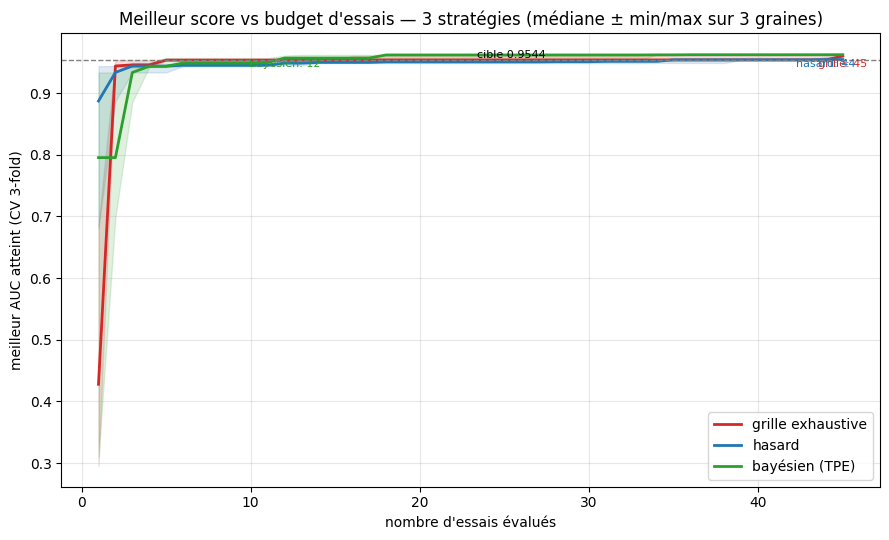

--- essais nécessaires pour atteindre la cible commune 0.9544 (médiane) ---
grille    : essai 45
hasard    : essai 44
bayésien  : essai 12


In [5]:
# Figure : meilleur score vs nombre d'essais (médiane + bande)
trials = np.arange(1, N_TRIALS + 1)

def med_band(c):
    return np.median(c, axis=0), c.min(axis=0), c.max(axis=0)

plt.figure(figsize=(9, 5.5))
labels = []
for curve, color, name in [(grid_curves, "#d62728", "grille exhaustive"),
                           (rand_curves, "#1f77b4", "hasard"),
                           (bayes_curves, "#2ca02c", "bayésien (TPE)")]:
    m, lo, hi = med_band(curve)
    plt.plot(trials, m, color=color, lw=2, label=name)
    plt.fill_between(trials, lo, hi, color=color, alpha=0.15)

# cible commune = pire des trois optima finaux (le premier que grid atteint en dernier)
target = min(np.median(grid_curves[:, -1]), np.median(rand_curves[:, -1]),
             np.median(bayes_curves[:, -1]))
plt.axhline(target, ls="--", color="gray", lw=1)
plt.text(N_TRIALS * 0.52, target + 0.002, f"cible {target:.4f}", fontsize=8)

def reach(c):
    hit = np.where(np.median(c, axis=0) >= target)[0]
    return int(hit[0]) + 1 if hit.size else N_TRIALS

for curve, color, name in [(grid_curves, "#d62728", "grille"),
                           (rand_curves, "#1f77b4", "hasard"),
                           (bayes_curves, "#2ca02c", "bayésien")]:
    at = reach(curve)
    plt.annotate(f"{name}: {at}", xy=(at, target), xytext=(at, target - 0.012),
                 fontsize=8, color=color, ha="center")

plt.xlabel("nombre d'essais évalués")
plt.ylabel("meilleur AUC atteint (CV 3-fold)")
plt.title("Meilleur score vs budget d'essais — 3 stratégies (médiane ± min/max sur 3 graines)")
plt.legend(loc="lower right"); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

print("--- essais nécessaires pour atteindre la cible commune "
      f"{target:.4f} (médiane) ---")
for curve, name in [(grid_curves, "grille"), (rand_curves, "hasard"),
                    (bayes_curves, "bayésien")]:
    print(f"{name:10s}: essai {reach(curve)}")

### Lecture du résultat

Trois constats, lus sur la figure et le résumé ci-dessus — pas sur une intuition :

1. **Le bayésien s'installe tôt.** Il atteint la cible commune vers le douzième essai, quand la grille et le hasard n'y arrivent qu'en toute fin de budget. C'est la concentration : chaque essai est choisi *à partir* des précédents, là où les deux autres stratégies dépensent leur budget sans mémoire.
2. **Grille et hasard finissent dans le même voisinage.** À ce budget, leur écart final reste faible au regard de l'amplitude totale entre configurations — qui va, sur ce problème, d'un MLP quasi dégénéré (pire que le hasard) à ~0.96 d'AUC. Le résultat « hasard ≥ grille » de Bergstra est un argument de **couverture** : il se manifeste quand l'espace est très large face au budget et que la bonne région est petite. Ici, le message dominant est la concentration du TPE, pas la hiérarchie grille/hasard.
3. **La bande min–max est là pour rappeler le protocole.** L'ordre entre deux stratégies proches se juge sur la médiane de plusieurs graines, jamais sur un run isolé — c'est exactement le point d'entrée de la section suivante.

## 6. Le protocole qui évite de se mentir : variance, gain marginal, quand s'arrêter

Un search honnête ne se résume pas à « la meilleure AUC ». Trois pièges à fermer :

1. **La métrique doit être honnête.** On *tune* sur un score mesuré en **validation**, jamais sur le test final. Le test, s'il existe, est un *report d'honnêteté*, pas un guide. Un search qui optimise le test (ou pire, le train) **fabrique** un résultat — cf. [2.5](2.5-Biais-Variance-CV-ROC.ipynb) (validation croisée) et [2.9](2.9-Grokking-Generalisation.ipynb) (la métrique qu'on optimise doit être la bonne).
2. **La variance inter-essais.** Une seule graine peut, par chance, faire paraître une stratégie meilleure qu'elle ne l'est. D'où le multi-seed et la bande min–max : on juge sur la **médiane**, pas sur le meilleur run.
3. **Le gain marginal.** Après un certain point, chaque essai supplémentaire n'améliore presque plus le meilleur score : la courbe s'aplatit. On définit explicitement un **critère d'arrêt** : *arrêter dès que, sur les `K` derniers essais, le meilleur score n'a pas gagné au moins `δ` points d'AUC.* Le `δ` se choisit en fonction du prix d'un essai et de la valeur métier d'un point d'AUC — c'est un arbitrage explicite, pas un réglage magique. C'est le geste qui économise le budget et qui distingue un search d'un puits sans fond.

In [6]:
# Critère d'arrêt explicite : gain marginal absolu sur les K derniers essais
K, DELTA = 10, 0.002       # si le meilleur n'a pas gagné 0.002 d'AUC en 10 essais -> stop

def stop_trial(best, K=10, delta=0.002):
    """Premier essai t tel que best[t] - best[t-K] < delta : la fenêtre de K
    essais n'a plus rien payé. S'arrêter là est le geste budget-honnête."""
    for t in range(K, len(best)):
        if best[t] - best[t - K] < delta:
            return t
    return len(best)       # jamais déclenché : le search paie encore

print(f"--- règle : arrêt si gain < {DELTA} d'AUC sur {K} essais (bayésien) ---")
for seed, curve in zip(SEEDS, bayes_curves):
    t = stop_trial(curve, K, DELTA)
    print(f"seed {seed:>2}: 1er essai={curve[0]:.4f}  final={curve[-1]:.4f}  "
          f"stop à l'essai {t} (meilleur={curve[t-1]:.4f}, "
          f"coût de l'arrêt={curve[-1] - curve[t-1]:+.4f}, "
          f"budget économisé={N_TRIALS - t} essais)")

# variance inter-seeds du meilleur final (à rapporter, pas à ignorer)
finals = np.array([c[-1] for c in bayes_curves])
print(f"\nvariance inter-seeds du meilleur final (bayésien) : std = {finals.std():.4f}")

--- règle : arrêt si gain < 0.002 d'AUC sur 10 essais (bayésien) ---
seed  0: 1er essai=0.9335  final=0.9623  stop à l'essai 24 (meilleur=0.9546, coût de l'arrêt=+0.0076, budget économisé=21 essais)
seed  1: 1er essai=0.3098  final=0.9643  stop à l'essai 21 (meilleur=0.9621, coût de l'arrêt=+0.0022, budget économisé=24 essais)
seed  7: 1er essai=0.7954  final=0.9623  stop à l'essai 14 (meilleur=0.9569, coût de l'arrêt=+0.0054, budget économisé=31 essais)

variance inter-seeds du meilleur final (bayésien) : std = 0.0010


## 7. Pont vers le reste du dépôt

Cette méthodologie n'est pas un cas isolé : c'est la lecture qu'on applique aux **sweeps de production** du dépôt.

* **ML-Training-Pipeline (QuantConnect)** : le `sweep` des modèles de trading (walk-forward 5-fold, ≥4 seeds, Diebold–Mariano) est exactement ce protocole — budget d'essais, validation hors train, **critère d'arrêt** sur le gain marginal, multi-seed. Ce notebook en donne le *pourquoi* : pourquoi un sweep qui ne s'arrête pas dépense du budget pour rien, et pourquoi on juge sur la médiane.
* **AgenticDataScience / Lab14** : l'*ablation* répond à « ce paramètre sert-il ? » — c'est la version ciblée du search (on gèle tout sauf une dimension). Les lunettes de la section 6 (variance, gain marginal) s'appliquent telles quelles.
* **ML-3** : le contraste *boîte-noire* — un AutoML .NET encapsule exactement la boucle « proposer → évaluer → modéliser » que l'on a déroulée à la main ici. L'avoir fait à la main rend l'AutoML lisible, pas magique.
* **2.5** (validation croisée) et **2.9** (choix de métrique) : les deux prérequis de la section 6 — impossible d'optimiser honnêtement sans eux.

### Exercice 1 — le coût de la grille (stub)

Compléter pour rendre *visible* le coût de la grille : calculer le nombre de combinaisons d'une grille à 6 hyperparamètres × 6 valeurs chacun, et afficher en combien d'essais un budget de 60 couvre le produit cartésien. Aucune exécution de modèle ici : de la simple arithmétique.

In [7]:
# Exercice 1 (stub) : coût de la grille
print("Exercice a completer")

Exercice a completer


### Exercice 2 — du hasard au bayésien (stub)

Transformer le `sample_random` ci-dessus en une étude Optuna **TPE** (`solver == "adam"` seulement), avec un budget de 30 essais, et comparer le *meilleur* final au meilleur du hasard sur la même graine. Que conclut-on sur le coût de la modélisation bayésienne ?

In [8]:
# Exercice 2 (stub) : random -> TPE
print("Exercice a completer")

Exercice a completer


### Exercice 3 — le critère d'arrêt (stub)

Écrire une fonction `admissible_stop(best_scores, K, TOL)` qui retourne l'essai à partir duquel le gain marginal relatif devient inférieur à `TOL`, et l'appliquer à la courbe bayésienne. Vérifier que le critère est **strict** (il ne triche pas en s'arrêtant trop tôt) en le comparant au gain réellement observé ensuite.

In [9]:
# Exercice 3 (stub) : critère d'arrêt strict
def admissible_stop(best_scores, K=10, TOL=0.01):
    # TODO etudiant
    return None

print("Exercice a completer")

Exercice a completer


## Synthèse

| Stratégie | Quand elle marche | Piège |
|---|---|---|
| **Grille** | dimension 1–2, espace bien compris | explose en dimension, maille aveugle aux bonnes régions |
| **Hasard** | dimension ≥ 3, peu de directions utiles | n'apprend pas du passé : budget mal réparti si fort coût d'évaluation |
| **Bayésien (TPE)** | budget serré, coût d'évaluation élevé | modélise la surface : réglages, mais coût de la modélisation |

**Le geste à retenir** : le search n'est pas une loterie, c'est un arbitrage budget ↔ gain. On fixe un *budget*, on choisit une *stratégie* adaptée (grille faible dimension, hasard par défaut, bayésien quand l'évaluation coûte cher), on juge sur la *médiane* d'un *multi-seed*, et on **s'arrête** quand le gain marginal devient négligeable. Savoir s'arrêter n'est pas paresse : c'est la différence entre un search et un puits sans fond.

## Conclusion et transition

Ce notebook a déroulé la **méthodologie** du tuning : poser le problème, mesurer le coût de la grille, comprendre pourquoi le hasard la bat, consommer un search bayésien, et fermer le protocole par un critère d'arrêt. Le [2.13](2.13-Analyse-Erreurs.ipynb) prend le relais sur le *diagnostic* : une fois le modèle réglé, comment lit-on ses erreurs ? La boucle est complète — réglage, puis lecture honnête.

## Références

* Bergstra & Bengio, *Random Search for Hyper-Parameter Optimization* (JMLR 2012) — le résultat géométrique « le hasard bat la grille en dimension ≥ 3 ».
* Akiba et al., *Optuna: A Next-generation Hyperparameter Optimization Framework* (KDD 2019) — le TPE consommé ici.
* Bergstra et al., *Algorithms for Hyper-Parameter Optimization* (NeurIPS 2011) — l'algorithme TPE.
* [2.5-Biais-Variance-CV-ROC](2.5-Biais-Variance-CV-ROC.ipynb) · [2.9-Grokking-Generalisation](2.9-Grokking-Generalisation.ipynb) — prérequis de la section 6.